In [14]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from datasets import load_dataset
import random
import re
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import numpy as np

In [2]:
# set notebook to use local GPU if available
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


## **Task 4.1**

In [3]:
MODEL_NAME = "declare-lab/flan-alpaca-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

model.eval()

/opt/miniconda3/envs/nlp_env/lib/python3.11/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
W0108 22:29:21.337000 19313 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
/opt/miniconda3/envs/nlp_env/lib/python3.11/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=768, out_features=2048, bias=False)
              (wi_1): Linear(in_features=768, out_features=2048, bias=False)
              (wo):

## **Task 4.2**

In [4]:
# Load ScienceQA dataset
scienceqa = load_dataset("derek-thomas/ScienceQA")

# Use training split (standard choice unless specified otherwise)
df = scienceqa["train"]

# Filter: text-only questions with exactly 4 answer options
filtered = []
for ex in df:
    if ex["image"] is None and len(ex["choices"]) == 4:
        filtered.append(ex)

# Randomly sample 200 questions
random.seed(42)
sampled = random.sample(filtered, 200)

In [ ]:
# Format questions with options A–D
def format_question(example):
    '''
    Formats the question and choices into a string in the following format:
    Question: <question>
    A) <choice 1>
    B) <choice 2>
    C) <choice 3>
    D) <choice 4>
    '''
    question = example["question"]
    choices = example["choices"]
    formatted = (
        f"Question: {question}\n"
        f"A) {choices[0]}\n"
        f"B) {choices[1]}\n"
        f"C) {choices[2]}\n"
        f"D) {choices[3]}"
    )
    return formatted

formatted_questions = [format_question(ex) for ex in sampled]

# Example output
print(formatted_questions[0])

Question: Select the amphibian.
A) wombat
B) barn owl
C) helmeted iguana
D) African bullfrog


## **Task 4.3**

In [6]:
# Make sure the model is on the same device you printed ("mps")
model = model.to(device)

In [7]:
LETTERS = ["A", "B", "C", "D"]

def extract_letter(text: str):
    # Robust: catches "A", "Answer: A", "(A)", "A)"
    m = re.search(r"\b([A-D])\b", text.strip())
    return m.group(1) if m else None

def build_direct_prompt(formatted_q: str) -> str:
    # Uses your existing formatted question string
    return (
        formatted_q
        + "\n\nRespond with only one letter (A, B, C, or D)."
    )

In [8]:
pred_letters = []
ground_truth_letters = []

with torch.no_grad():
    for ex, fq in tqdm(list(zip(sampled, formatted_questions)), total=len(sampled)):
        prompt = build_direct_prompt(fq)

        inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)

        out_ids = model.generate(
            **inputs,
            max_new_tokens=5,     # only need a single letter
            do_sample=False       # greedy decoding (more stable)
        )

        out_text = tokenizer.decode(out_ids[0], skip_special_tokens=True).strip()
        pred = extract_letter(out_text)

        # Ground-truth answer is typically an index 0..3 in ScienceQA-style datasets
        gold = LETTERS[ex["answer"]] if isinstance(ex["answer"], int) else ex["answer"]

        pred_letters.append(pred)
        ground_truth_letters.append(gold)

100%|██████████| 200/200 [00:40<00:00,  4.90it/s]


In [ ]:
# If parsing fails sometimes, treat as wrong (None != gold)
acc = sum(p == g for p, g in zip(pred_letters, ground_truth_letters)) / len(ground_truth_letters)

print(f"Direct-answer accuracy (no-CoT) on 200 questions: {acc:.3f}")

# inspect some failures
for i in range(5):
    if pred_letters[i] != ground_truth_letters[i]:
        print("----")
        print(formatted_questions[i])
        print("Model output:", pred_letters[i])
        print("Ground-truth answer:", ground_truth_letters[i])

Direct-answer accuracy (no-CoT) on 200 questions: 0.495
----
Question: Which type of sentence is this?
Aisha is a competitive horseback rider, and she will be competing in the next World Equestrian Games, which are held every four years.
A) complex
B) compound-complex
C) simple
D) compound
Model output: C
Ground-truth answer: B


## **Task 4.4**

In [ ]:
def build_cot_prompt(formatted_q: str) -> str:
    """Build a Chain of Thought prompt with explicit formatting instructions."""
    instruction = """You are a careful reasoning assistant that answers multiple-choice questions about science. First, think step by step. Then, give the final answer. Format exactly as:
Reasoning: <step 1>
Reasoning: <step 2>
Reasoning: <step 3>
Answer: <final letter>"""
    
    return f"{formatted_q}\n\n{instruction}"

def extract_cot_output(text: str):
    """Extract reasoning steps and final answer from CoT output."""
    reasoning_steps = []
    final_answer = None
    
    # Extract reasoning steps (look for "Reasoning:" lines)
    reasoning_pattern = r"Reasoning:\s*(.+?)(?=\nReasoning:|\nAnswer:|$)"
    reasoning_matches = re.findall(reasoning_pattern, text, re.IGNORECASE | re.DOTALL)
    
    # Take first 3 reasoning steps (or all if less than 3)
    reasoning_steps = [match.strip() for match in reasoning_matches[:3]]
    
    # Extract final answer (look for "Answer:" line)
    answer_pattern = r"Answer:\s*([A-D])"
    answer_match = re.search(answer_pattern, text, re.IGNORECASE)
    if answer_match:
        final_answer = answer_match.group(1).upper()
    else:
        # Fallback: try to extract any letter at the end
        final_answer = extract_letter(text)
    
    return reasoning_steps, final_answer

In [ ]:
# Run inference with CoT prompts
cot_reasoning_steps = []
cot_pred_letters = []

with torch.no_grad():
    for ex, fq in tqdm(list(zip(sampled, formatted_questions)), total=len(sampled)):
        prompt = build_cot_prompt(fq)
        
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
        
        out_ids = model.generate(
            **inputs,
            max_new_tokens=200,  # Need more tokens for reasoning steps
            do_sample=False      # greedy decoding
        )
        
        out_text = tokenizer.decode(out_ids[0], skip_special_tokens=True).strip()
        reasoning, pred = extract_cot_output(out_text)
        
        cot_reasoning_steps.append(reasoning)
        cot_pred_letters.append(pred)

100%|██████████| 200/200 [00:39<00:00,  5.07it/s]


In [12]:
# Calculate accuracy
cot_acc = sum(p == g for p, g in zip(cot_pred_letters, ground_truth_letters)) / len(ground_truth_letters)
print(f"CoT accuracy on 200 questions: {cot_acc:.3f}")

# Display example output
print("\n--- Example CoT Output ---")
example_idx = 0
print(formatted_questions[example_idx])
print("\nReasoning steps:")
for i, step in enumerate(cot_reasoning_steps[example_idx], 1):
    print(f"  Step {i}: {step}")
print(f"\nPredicted answer: {cot_pred_letters[example_idx]}")
print(f"Ground-truth answer: {ground_truth_letters[example_idx]}")

CoT accuracy on 200 questions: 0.445

--- Example CoT Output ---
Question: Select the amphibian.
A) wombat
B) barn owl
C) helmeted iguana
D) African bullfrog

Reasoning steps:

Predicted answer: D
Ground-truth answer: D


In [13]:
# Add this after your CoT inference loop to inspect actual outputs
print("=== Inspecting Model Outputs ===\n")

# Check a few examples
for i in range(3):
    print(f"\n--- Example {i+1} ---")
    prompt = build_cot_prompt(formatted_questions[i])
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
    
    with torch.no_grad():
        out_ids = model.generate(
            **inputs,
            max_new_tokens=200,
            do_sample=False
        )
    
    out_text = tokenizer.decode(out_ids[0], skip_special_tokens=True).strip()
    
    print("Full model output:")
    print(repr(out_text))  # repr() shows exact characters including newlines
    print("\nExtracted reasoning:", cot_reasoning_steps[i])
    print("Extracted answer:", cot_pred_letters[i])
    print("Ground truth:", ground_truth_letters[i])
    print("-" * 50)

=== Inspecting Model Outputs ===


--- Example 1 ---
Full model output:
'D) African bullfrog'

Extracted reasoning: []
Extracted answer: D
Ground truth: D
--------------------------------------------------

--- Example 2 ---
Full model output:
'D) 20 feet'

Extracted reasoning: []
Extracted answer: D
Ground truth: D
--------------------------------------------------

--- Example 3 ---
Full model output:
'C) simple'

Extracted reasoning: []
Extracted answer: C
Ground truth: B
--------------------------------------------------


## **Task 4.5**

In [15]:
# Perform flip analysis
flip_to_correct = []      # baseline wrong, CoT correct
flip_to_incorrect = []     # baseline correct, CoT wrong
correct_correct = []       # both correct
incorrect_incorrect = []   # both incorrect

for i in range(len(pred_letters)):
    baseline_correct = (pred_letters[i] == ground_truth_letters[i])
    cot_correct = (cot_pred_letters[i] == ground_truth_letters[i])
    
    if not baseline_correct and cot_correct:
        flip_to_correct.append(i)
    elif baseline_correct and not cot_correct:
        flip_to_incorrect.append(i)
    elif baseline_correct and cot_correct:
        correct_correct.append(i)
    else:  # both incorrect
        incorrect_incorrect.append(i)

In [25]:
# Counts for each category
count_flip_to_correct = len(flip_to_correct)
count_flip_to_incorrect = len(flip_to_incorrect)
count_correct_correct = len(correct_correct)
count_incorrect_incorrect = len(incorrect_incorrect)

# Calculate accuracies (percentages)
total_questions = len(pred_letters)
acc_flip_to_correct = count_flip_to_correct / total_questions
acc_flip_to_incorrect = count_flip_to_incorrect / total_questions
acc_correct_correct = count_correct_correct / total_questions
acc_incorrect_incorrect = count_incorrect_incorrect / total_questions

# Report counts
print("=== Flip Analysis Results ===\n")
print(f"Flip-to-correct: {count_flip_to_correct}")
print(f"Flip-to-incorrect: {count_flip_to_incorrect}")
print(f"Correct-Correct: {count_correct_correct}")
print(f"Incorrect-Incorrect: {count_incorrect_incorrect}")
print(f"\nTotal: {count_flip_to_correct + count_flip_to_incorrect + count_correct_correct + count_incorrect_incorrect}")

# Report accuracies (percentages only)
print(f"Flip-to-correct: {acc_flip_to_correct:.3f}")
print(f"Flip-to-incorrect: {acc_flip_to_incorrect:.3f}")
print(f"Correct-Correct: {acc_correct_correct:.3f}")
print(f"Incorrect-Incorrect: {acc_incorrect_incorrect:.3f}")

=== Flip Analysis Results ===

Flip-to-correct: 6
Flip-to-incorrect: 16
Correct-Correct: 83
Incorrect-Incorrect: 95

Total: 200
Flip-to-correct: 0.030
Flip-to-incorrect: 0.080
Correct-Correct: 0.415
Incorrect-Incorrect: 0.475


In [17]:
# Calculate accuracies
baseline_acc = sum(p == g for p, g in zip(pred_letters, ground_truth_letters)) / len(ground_truth_letters)
cot_acc = sum(p == g for p, g in zip(cot_pred_letters, ground_truth_letters)) / len(ground_truth_letters)

print(f"\n=== Accuracy Results ===")
print(f"Overall accuracy without CoT (baseline): {baseline_acc:.3f}")
print(f"Overall accuracy with CoT: {cot_acc:.3f}")


=== Accuracy Results ===
Overall accuracy without CoT (baseline): 0.495
Overall accuracy with CoT: 0.445


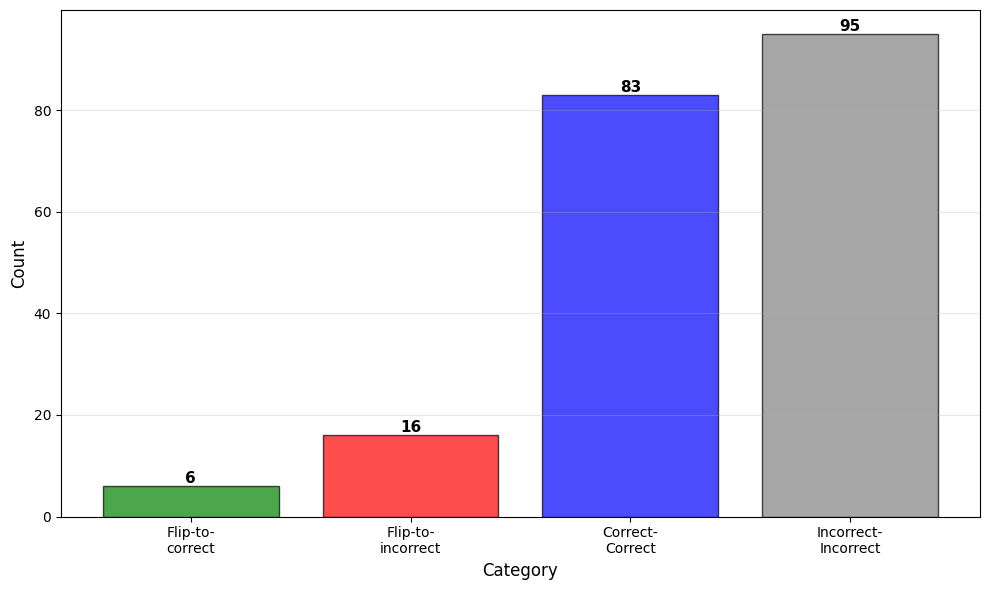

In [19]:
# Visualize the counts in a bar plot
categories = ['Flip-to-\ncorrect', 'Flip-to-\nincorrect', 'Correct-\nCorrect', 'Incorrect-\nIncorrect']
counts = [count_flip_to_correct, count_flip_to_incorrect, count_correct_correct, count_incorrect_incorrect]

plt.figure(figsize=(10, 6))
bars = plt.bar(categories, counts, color=['green', 'red', 'blue', 'gray'], alpha=0.7, edgecolor='black')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
#plt.title('Flip Analysis: Comparison of Baseline (no CoT) vs CoT Predictions', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add count labels on top of bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{count}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## **Task 4.6**

In [27]:
def inspect_examples(category_name, indices, max_samples=20):
    """Inspect examples from a specific category."""
    # Randomly sample up to max_samples (or all if fewer)
    sample_size = min(len(indices), max_samples)
    sampled_indices = random.sample(indices, sample_size) if len(indices) > max_samples else indices
    
    print(f"\n{'='*80}")
    print(f"Category: {category_name}")
    print(f"Total examples: {len(indices)}, Inspecting: {len(sampled_indices)}")
    print(f"{'='*80}\n")
    
    for idx, example_idx in enumerate(sampled_indices, 1):
        print(f"\n--- Example {idx}/{len(sampled_indices)} (Index {example_idx}) ---")
        print(f"\n{formatted_questions[example_idx]}")
        
        print(f"\nBaseline prediction (no CoT): {pred_letters[example_idx]}")
        print(f"CoT prediction: {cot_pred_letters[example_idx]}")
        print(f"Ground truth: {ground_truth_letters[example_idx]}")
        
        # Display reasoning steps
        reasoning = cot_reasoning_steps[example_idx]
        if reasoning:
            print(f"\nReasoning steps:")
            for i, step in enumerate(reasoning, 1):
                print(f"  Step {i}: {step}")
        else:
            print(f"\nReasoning steps: [No reasoning steps extracted - model did not follow CoT format]")
        
        # Category-specific inspection prompts
        if category_name == "Flip-to-incorrect":
            print(f"\n[Inspection: Does the reasoning look plausible but misleading? Nonsensical?]")
        elif category_name == "Incorrect-Incorrect":
            print(f"\n[Inspection: Is the model genuinely reasoning (but wrong), or just explaining its wrong guess?]")
        elif category_name == "Correct-Correct":
            print(f"\n[Inspection: Is the CoT adding useful justification, or does it seem redundant? Is it worth generating CoT in such cases?]")
        
        print("-" * 80)

In [28]:
# Set seed for reproducibility
random.seed(42)

# Inspect each category
inspect_examples("Flip-to-correct", flip_to_correct, max_samples=20)
inspect_examples("Flip-to-incorrect", flip_to_incorrect, max_samples=20)
inspect_examples("Correct-Correct", correct_correct, max_samples=20)
inspect_examples("Incorrect-Incorrect", incorrect_incorrect, max_samples=20)

# Summary of patterns
print(f"\n\n{'='*80}")
print("SUMMARY: Patterns in Questions/Topics")
print(f"{'='*80}")
print("\nFor Flip-to-correct cases:")
print("- What kinds of questions tend to flip to correct?")
print("- Are there common topics or question types?")
print("\nFor Flip-to-incorrect cases:")
print("- What kinds of questions tend to flip to incorrect?")
print("- Are there patterns in the reasoning that lead to wrong answers?")
print(f"{'='*80}")



Category: Flip-to-correct
Total examples: 6, Inspecting: 6


--- Example 1/6 (Index 15) ---

Question: How long is a tennis racket?
A) 23 inches
B) 23 miles
C) 23 yards
D) 23 feet

Baseline prediction (no CoT): D
CoT prediction: A
Ground truth: A

Reasoning steps: [No reasoning steps extracted - model did not follow CoT format]
--------------------------------------------------------------------------------

--- Example 2/6 (Index 101) ---

Question: Which type of sentence is this?
Lorraine Hansberry wrote the widely acclaimed 1959 Broadway play A Raisin in the Sun, and her accomplishment opened the door for other African American playwrights.
A) compound
B) complex
C) simple
D) compound-complex

Baseline prediction (no CoT): C
CoT prediction: A
Ground truth: A

Reasoning steps: [No reasoning steps extracted - model did not follow CoT format]
--------------------------------------------------------------------------------

--- Example 3/6 (Index 112) ---

Question: Select the item tha

In [31]:
# Configuration and Environment Information
import sys
import platform

# Try to use importlib.metadata (Python 3.8+) or fall back to pkg_resources
try:
    from importlib.metadata import version, distributions
    USE_IMPORTLIB = True
except ImportError:
    try:
        import pkg_resources
        USE_IMPORTLIB = False
    except ImportError:
        USE_IMPORTLIB = None

def get_package_version(package_name):
    """Get version of a package."""
    if USE_IMPORTLIB:
        try:
            return version(package_name)
        except:
            return "Not installed"
    elif USE_IMPORTLIB is False:
        try:
            return pkg_resources.get_distribution(package_name).version
        except:
            return "Not installed"
    else:
        return "Unable to check"

# Print Python version
print("Task 4")
print("=" * 80)
print("PYTHON VERSION")
print("=" * 80)
print(f"Python: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Architecture: {platform.architecture()[0]}")
print()

# List of packages to check (based on imports in this notebook)
packages_to_check = [
    'torch',
    'transformers',
    'datasets',
    'tqdm',
    'matplotlib',
    'numpy',
]

# Print package versions
print("=" * 80)
print("PACKAGE VERSIONS")
print("=" * 80)

for package in packages_to_check:
    pkg_version = get_package_version(package)
    print(f"{package:20s}: {pkg_version}")

print("=" * 80)

Task 4
PYTHON VERSION
Python: 3.11.11 (main, Dec 11 2024, 10:25:04) [Clang 14.0.6 ]
Platform: macOS-15.6.1-arm64-arm-64bit
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Architecture: 64bit

PACKAGE VERSIONS
torch               : 2.7.1
transformers        : 4.31.0
datasets            : 3.6.0
tqdm                : 4.67.1
matplotlib          : 3.10.3
numpy               : 1.25.2
